# 11 — Class Geometry and Label Audit

## Obiettivo

Analizzare lo spazio latente prodotto dal miglior modello Siamese
senza effettuare ulteriore training.

L'obiettivo è determinare se il limite osservato nella classificazione
12-way (~31% accuracy) derivi principalmente da:

- scarsa separazione dello spazio latente;
- elevata variabilità intra-classe;
- sovrapposizione tra specifiche classi tumorali;
- possibile ridondanza o ambiguità delle label;
- difficoltà specifica della classe Healthy.

Modello analizzato:

- FCGR k=6
- CNN Encoder V3
- Dynamic Semi-Hard Siamese training
- Euclidean distance
- embedding 128D L2-normalizzato

L'analisi utilizza esclusivamente train/reference e validation.
Il test set rimane intatto.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# PATHS
# ============================================================

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

FCGR_DIR = (
    PROCESSED_DIR
    / "fcgr_cache"
)

ARTIFACTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "class_geometry_audit"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MANIFEST_PATH = (
    PROCESSED_DIR
    / "siamese_tumor_healthy_manifest.tsv"
)

CLASS_MAPPING_PATH = (
    PROCESSED_DIR
    / "siamese_tumor_healthy_class_mapping.tsv"
)

VAL_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_val_pair_pool.tsv"
)

FCGR_PATH = (
    FCGR_DIR
    / "fcgr_k6.npy"
)

FCGR_INDEX_PATH = (
    FCGR_DIR
    / "fcgr_k6_index.tsv"
)

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "siamese_dynamic_semihard_tumor_healthy"
    / "dynamic_semihard_v3_best.pt"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

N_CLASSES = 12
EMBEDDING_DIM = 128
RANDOM_STATE = 42

print("Device:", DEVICE)
print("Checkpoint:", CHECKPOINT_PATH)
print("Checkpoint exists:", CHECKPOINT_PATH.exists())

Device: cuda
Checkpoint: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_dynamic_semihard_tumor_healthy\dynamic_semihard_v3_best.pt
Checkpoint exists: True


In [2]:
# ============================================================
# LOAD DATASET + FCGR k=6
# ============================================================

metadata = pd.read_csv(
    MANIFEST_PATH,
    sep="\t",
    dtype={"id": str}
)

metadata["class_id"] = (
    metadata["class_id"]
    .astype(int)
)


class_mapping = pd.read_csv(
    CLASS_MAPPING_PATH,
    sep="\t"
)


# ============================================================
# TRAIN / REFERENCE SET
# ============================================================

full_train_metadata = (
    metadata[
        metadata["split_cluster"]
        ==
        "train"
    ]
    .copy()
    .reset_index(drop=True)
)


train_counts = (
    full_train_metadata["class_id"]
    .value_counts()
    .sort_index()
)


MIN_CLASS_SIZE = int(
    train_counts.min()
)


balanced_parts = []


for class_id in sorted(
    full_train_metadata["class_id"].unique()
):

    class_df = (
        full_train_metadata[
            full_train_metadata["class_id"]
            ==
            class_id
        ]
    )

    sampled = class_df.sample(
        n=MIN_CLASS_SIZE,
        replace=False,
        random_state=(
            RANDOM_STATE
            +
            int(class_id)
        )
    )

    balanced_parts.append(
        sampled
    )


train_metadata = (
    pd.concat(
        balanced_parts,
        ignore_index=True
    )
    .reset_index(drop=True)
)


# ============================================================
# VALIDATION
# ============================================================

old_to_new = dict(
    zip(
        class_mapping["original_class_id"].astype(int),
        class_mapping["class_id"].astype(int)
    )
)


included_original_ids = set(
    old_to_new.keys()
)


val_original = pd.read_csv(
    VAL_POOL_PATH,
    sep="\t",
    dtype={"id": str}
)


val_original["class_id"] = (
    val_original["class_id"]
    .astype(int)
)


val_metadata = (
    val_original[
        val_original["class_id"]
        .isin(included_original_ids)
    ]
    .copy()
    .reset_index(drop=True)
)


val_metadata["original_class_id"] = (
    val_metadata["class_id"]
)


val_metadata["class_id"] = (
    val_metadata["original_class_id"]
    .map(old_to_new)
    .astype(int)
)


# ============================================================
# FCGR CACHE
# ============================================================

fcgr_memmap = np.load(
    FCGR_PATH,
    mmap_mode="r"
)


fcgr_index = pd.read_csv(
    FCGR_INDEX_PATH,
    sep="\t",
    dtype={"id": str}
)


id_to_fcgr_row = dict(
    zip(
        fcgr_index["id"],
        fcgr_index["fcgr_row"]
    )
)


print("=" * 72)
print("AUDIT DATA")
print("=" * 72)

print(
    "Reference train:",
    len(train_metadata)
)

print(
    "Validation:",
    len(val_metadata)
)

print(
    "Classes:",
    train_metadata["class_id"].nunique()
)

print(
    "FCGR shape:",
    fcgr_memmap.shape
)

print(
    "Missing train:",
    (~train_metadata["id"].isin(id_to_fcgr_row)).sum()
)

print(
    "Missing val:",
    (~val_metadata["id"].isin(id_to_fcgr_row)).sum()
)

AUDIT DATA
Reference train: 25332
Validation: 9753
Classes: 12
FCGR shape: (150272, 64, 64)
Missing train: 0
Missing val: 0


In [3]:
# ============================================================
# CNN ENCODER V3
# ============================================================

class FCGRCNNEncoderV3(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                32
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                64
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.AdaptiveAvgPool2d(
                (4, 4)
            )
        )


        self.embedding_head = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                256,
                embedding_dim
            )
        )


    def forward(
        self,
        x
    ):

        x = self.features(x)

        z = self.embedding_head(x)

        return F.normalize(
            z,
            p=2,
            dim=1,
            eps=1e-8
        )


class SiameseV3(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()

        self.encoder = FCGRCNNEncoderV3(
            embedding_dim=embedding_dim
        )


    def forward(
        self,
        x1,
        x2
    ):

        batch_size = x1.shape[0]

        x = torch.cat(
            [x1, x2],
            dim=0
        )

        z = self.encoder(x)

        return (
            z[:batch_size],
            z[batch_size:]
        )

In [4]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

model = SiameseV3(
    embedding_dim=EMBEDDING_DIM
).to(DEVICE)


checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)


model.load_state_dict(
    checkpoint["model_state_dict"]
)


model.eval()


print("=" * 72)
print("BEST MODEL LOADED")
print("=" * 72)

print(
    "Checkpoint epoch:",
    checkpoint.get("epoch", "not stored")
)

print(
    "Model on:",
    DEVICE
)

BEST MODEL LOADED
Checkpoint epoch: 11
Model on: cuda


In [5]:
# ============================================================
# SINGLE SAMPLE DATASET
# ============================================================

class SingleFCGRDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row
    ):

        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )

        self.fcgr_memmap = fcgr_memmap


        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )


        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )


    def __len__(self):

        return len(self.metadata)


    def __getitem__(
        self,
        index
    ):

        x = np.array(
            self.fcgr_memmap[
                int(self.rows[index])
            ],
            dtype=np.float32,
            copy=True
        )


        return {
            "x":
                torch.from_numpy(x)
                .unsqueeze(0),

            "label":
                torch.tensor(
                    self.labels[index],
                    dtype=torch.long
                )
        }


reference_dataset = SingleFCGRDataset(
    train_metadata,
    fcgr_memmap,
    id_to_fcgr_row
)


validation_dataset = SingleFCGRDataset(
    val_metadata,
    fcgr_memmap,
    id_to_fcgr_row
)


reference_loader = DataLoader(
    reference_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


validation_loader = DataLoader(
    validation_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [6]:
# ============================================================
# EXTRACT EMBEDDINGS
# ============================================================

@torch.no_grad()
def extract_embeddings(
    encoder,
    loader
):

    encoder.eval()

    embeddings = []
    labels = []


    for batch in loader:

        x = batch["x"].to(
            DEVICE,
            non_blocking=True
        )


        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):

            z = encoder(x)


        embeddings.append(
            z.float()
            .cpu()
            .numpy()
        )


        labels.append(
            batch["label"]
            .numpy()
        )


    return (
        np.concatenate(embeddings),
        np.concatenate(labels)
    )


reference_embeddings, reference_labels = (
    extract_embeddings(
        model.encoder,
        reference_loader
    )
)


val_embeddings, val_labels = (
    extract_embeddings(
        model.encoder,
        validation_loader
    )
)


print("=" * 72)
print("EMBEDDINGS")
print("=" * 72)

print(
    "Reference:",
    reference_embeddings.shape
)

print(
    "Validation:",
    val_embeddings.shape
)

print(
    "Mean norm:",
    np.linalg.norm(
        val_embeddings,
        axis=1
    ).mean()
)

EMBEDDINGS
Reference: (25332, 128)
Validation: (9753, 128)
Mean norm: 1.0


In [7]:
# ============================================================
# CLASS CENTROIDS
# ============================================================

centroids = []


for class_id in range(
    N_CLASSES
):

    class_embeddings = (
        reference_embeddings[
            reference_labels == class_id
        ]
    )


    centroid = class_embeddings.mean(
        axis=0
    )


    centroid = (
        centroid
        /
        (
            np.linalg.norm(centroid)
            +
            1e-12
        )
    )


    centroids.append(
        centroid
    )


centroids = np.stack(
    centroids
)


print(
    "Centroids:",
    centroids.shape
)

Centroids: (12, 128)


In [8]:
# ============================================================
# CENTROID DISTANCE MATRIX
# ============================================================

centroid_distance_matrix = np.linalg.norm(

    centroids[:, None, :]
    -
    centroids[None, :, :],

    axis=2
)


class_names = (
    class_mapping
    .sort_values("class_id")
    ["disease_clean"]
    .tolist()
)


distance_df = pd.DataFrame(
    centroid_distance_matrix,
    index=class_names,
    columns=class_names
)


display(
    distance_df.round(4)
)

,gastric cancer,healthy,ovarian cancer,prostate cancer,colorectal cancer,lymphoma,cervical adenocarcinoma,leukemia,hypopharyngeal squamous cell carcinoma,glioblastoma cancer,melanoma,hypopharynx cancer
gastric cancer,0.0000,0.3644,0.5944,0.4938,0.3386,0.4342,0.3117,0.2704,0.4895,0.2455,0.4649,0.4982
healthy,0.3644,0.0000,0.4457,0.3786,0.4277,0.4912,0.4448,0.1913,0.2616,0.2275,0.3682,0.2775
ovarian cancer,0.5944,0.4457,0.0000,0.1330,0.4455,0.3557,0.4456,0.5127,0.4326,0.4721,0.7141,0.4280
prostate cancer,0.4938,0.3786,0.1330,0.0000,0.3205,0.2533,0.3287,0.4275,0.3816,0.3768,0.6486,0.3768
colorectal cancer,0.3386,0.4277,0.4455,0.3205,0.0000,0.2141,0.1156,0.4040,0.4733,0.3428,0.6015,0.4687
lymphoma,0.4342,0.4912,0.3557,0.2533,0.2141,0.0000,0.1713,0.4606,0.5351,0.4008,0.6757,0.5318
cervical adenocarcinoma,0.3117,0.4448,0.4456,0.3287,0.1156,0.1713,0.0000,0.3996,0.5211,0.3452,0.6003,0.5204
leukemia,0.2704,0.1913,0.5127,0.4275,0.4040,0.4606,0.3996,0.0000,0.3630,0.1086,0.3735,0.3810
hypopharyngeal squamous cell carcinoma,0.4895,0.2616,0.4326,0.3816,0.4733,0.5351,0.5211,0.3630,0.0000,0.3243,0.5995,0.0295
glioblastoma cancer,0.2455,0.2275,0.4721,0.3768,0.3428,0.4008,0.3452,0.1086,0.3243,0.0000,0.4623,0.3387


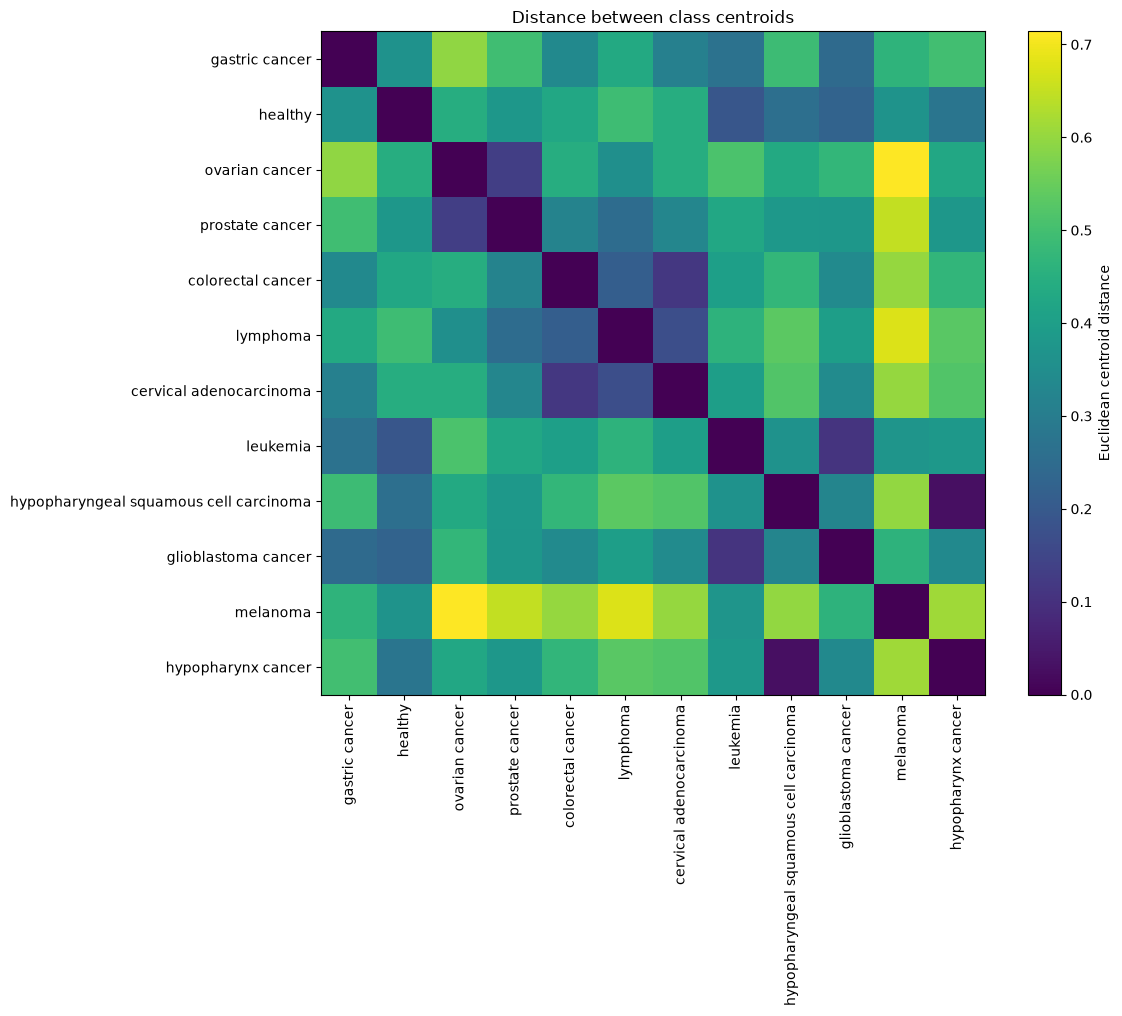

In [9]:
# ============================================================
# CENTROID DISTANCE HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 10)
)


im = ax.imshow(
    centroid_distance_matrix
)


ax.set_xticks(
    np.arange(N_CLASSES)
)

ax.set_yticks(
    np.arange(N_CLASSES)
)


ax.set_xticklabels(
    class_names,
    rotation=90
)

ax.set_yticklabels(
    class_names
)


fig.colorbar(
    im,
    ax=ax,
    label="Euclidean centroid distance"
)


ax.set_title(
    "Distance between class centroids"
)


plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# NEAREST CLASS PER CLASS
# ============================================================

nearest_rows = []


for class_id in range(
    N_CLASSES
):

    distances = (
        centroid_distance_matrix[
            class_id
        ].copy()
    )


    distances[
        class_id
    ] = np.inf


    nearest_class_id = int(
        np.argmin(distances)
    )


    nearest_rows.append(
        {
            "class_id":
                class_id,

            "class_name":
                class_names[class_id],

            "nearest_class_id":
                nearest_class_id,

            "nearest_class":
                class_names[
                    nearest_class_id
                ],

            "centroid_distance":
                distances[
                    nearest_class_id
                ]
        }
    )


nearest_df = pd.DataFrame(
    nearest_rows
)


display(
    nearest_df.sort_values(
        "centroid_distance"
    )
)

,class_id,class_name,nearest_class_id,nearest_class,centroid_distance
11,11,hypopharynx cancer,8,hypopharyngeal squamous cell carcinoma,0.029529
8,8,hypopharyngeal squamous cell carcinoma,11,hypopharynx cancer,0.029529
7,7,leukemia,9,glioblastoma cancer,0.108622
9,9,glioblastoma cancer,7,leukemia,0.108622
6,6,cervical adenocarcinoma,4,colorectal cancer,0.115623
4,4,colorectal cancer,6,cervical adenocarcinoma,0.115623
2,2,ovarian cancer,3,prostate cancer,0.132968
3,3,prostate cancer,2,ovarian cancer,0.132968
5,5,lymphoma,6,cervical adenocarcinoma,0.171309
1,1,healthy,7,leukemia,0.191322


In [11]:
# ============================================================
# INTRA-CLASS DISPERSION
# ============================================================

intra_rows = []


for class_id in range(
    N_CLASSES
):

    class_embeddings = (
        reference_embeddings[
            reference_labels == class_id
        ]
    )


    centroid = centroids[
        class_id
    ]


    distances = np.linalg.norm(
        class_embeddings
        -
        centroid[None, :],
        axis=1
    )


    intra_rows.append(
        {
            "class_id":
                class_id,

            "class_name":
                class_names[class_id],

            "n_samples":
                len(class_embeddings),

            "mean_intra_distance":
                distances.mean(),

            "median_intra_distance":
                np.median(distances),

            "std_intra_distance":
                distances.std(),

            "p90_intra_distance":
                np.percentile(
                    distances,
                    90
                )
        }
    )


intra_df = pd.DataFrame(
    intra_rows
)


display(
    intra_df.sort_values(
        "mean_intra_distance",
        ascending=False
    )
)

,class_id,class_name,n_samples,mean_intra_distance,median_intra_distance,std_intra_distance,p90_intra_distance
1,1,healthy,2111,0.500679,0.493336,0.072840,0.602552
7,7,leukemia,2111,0.477688,0.473920,0.099811,0.616684
9,9,glioblastoma cancer,2111,0.472300,0.462163,0.095226,0.613860
3,3,prostate cancer,2111,0.455061,0.430383,0.100680,0.599494
4,4,colorectal cancer,2111,0.440231,0.417128,0.093973,0.577235
6,6,cervical adenocarcinoma,2111,0.437075,0.421487,0.081011,0.552860
8,8,hypopharyngeal squamous cell carcinoma,2111,0.423509,0.380791,0.121130,0.612829
5,5,lymphoma,2111,0.418451,0.384895,0.109417,0.593546
11,11,hypopharynx cancer,2111,0.418324,0.377839,0.121215,0.605492
0,0,gastric cancer,2111,0.406413,0.374473,0.119361,0.594952


In [12]:
# ============================================================
# CLASS SEPARATION RATIO
# ============================================================

audit_df = (
    intra_df
    .merge(
        nearest_df,
        on=[
            "class_id",
            "class_name"
        ]
    )
)


audit_df[
    "separation_ratio"
] = (
    audit_df[
        "centroid_distance"
    ]
    /
    (
        audit_df[
            "mean_intra_distance"
        ]
        +
        1e-12
    )
)


audit_df = audit_df[
    [
        "class_id",
        "class_name",
        "n_samples",
        "mean_intra_distance",
        "median_intra_distance",
        "nearest_class",
        "centroid_distance",
        "separation_ratio"
    ]
]


display(
    audit_df.sort_values(
        "separation_ratio"
    )
)

,class_id,class_name,n_samples,mean_intra_distance,median_intra_distance,nearest_class,centroid_distance,separation_ratio
8,8,hypopharyngeal squamous cell carcinoma,2111,0.423509,0.380791,hypopharynx cancer,0.029529,0.069724
11,11,hypopharynx cancer,2111,0.418324,0.377839,hypopharyngeal squamous cell carcinoma,0.029529,0.070588
7,7,leukemia,2111,0.477688,0.473920,glioblastoma cancer,0.108622,0.227392
9,9,glioblastoma cancer,2111,0.472300,0.462163,leukemia,0.108622,0.229986
4,4,colorectal cancer,2111,0.440231,0.417128,cervical adenocarcinoma,0.115623,0.262643
6,6,cervical adenocarcinoma,2111,0.437075,0.421487,colorectal cancer,0.115623,0.264539
3,3,prostate cancer,2111,0.455061,0.430383,ovarian cancer,0.132968,0.292197
2,2,ovarian cancer,2111,0.386453,0.337158,prostate cancer,0.132968,0.344072
1,1,healthy,2111,0.500679,0.493336,leukemia,0.191322,0.382125
5,5,lymphoma,2111,0.418451,0.384895,cervical adenocarcinoma,0.171309,0.409388


In [13]:
# ============================================================
# TOP-20 REFERENCE-BANK FOR AUDIT
# ============================================================

@torch.no_grad()
def reference_bank_predict(
    query_embeddings,
    reference_embeddings,
    reference_labels,
    k=20,
    batch_size=256
):

    references_by_class = {}

    for class_id in range(N_CLASSES):

        refs = reference_embeddings[
            reference_labels == class_id
        ]

        references_by_class[class_id] = (
            torch.from_numpy(refs)
            .float()
            .to(DEVICE)
        )


    predictions = []


    for start in range(
        0,
        len(query_embeddings),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(query_embeddings)
        )


        q = (
            torch.from_numpy(
                query_embeddings[start:end]
            )
            .float()
            .to(DEVICE)
        )


        class_scores = []


        for class_id in range(N_CLASSES):

            refs = references_by_class[
                class_id
            ]


            similarity = (
                q @ refs.T
            )


            distances = torch.sqrt(
                torch.clamp(
                    2.0
                    -
                    2.0 * similarity,
                    min=0.0
                )
                +
                1e-12
            )


            nearest = torch.topk(
                distances,
                k=k,
                dim=1,
                largest=False
            ).values


            score = nearest.mean(
                dim=1
            )


            class_scores.append(
                score
            )


        class_scores = torch.stack(
            class_scores,
            dim=1
        )


        batch_predictions = (
            class_scores
            .argmin(dim=1)
        )


        predictions.append(
            batch_predictions
            .cpu()
            .numpy()
        )


    return np.concatenate(
        predictions
    )


val_predictions = reference_bank_predict(
    query_embeddings=val_embeddings,
    reference_embeddings=reference_embeddings,
    reference_labels=reference_labels,
    k=20
)

In [14]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    val_labels,
    val_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

                                        precision    recall  f1-score   support

                        gastric cancer     0.3623    0.5170    0.4260      1000
                               healthy     0.4862    0.1940    0.2773      1000
                        ovarian cancer     0.4026    0.4920    0.4428      1000
                       prostate cancer     0.2722    0.0920    0.1375      1000
                     colorectal cancer     0.2821    0.3050    0.2931      1000
                              lymphoma     0.3202    0.4050    0.3576      1000
               cervical adenocarcinoma     0.2549    0.2600    0.2574      1000
                              leukemia     0.3299    0.1910    0.2419      1000
hypopharyngeal squamous cell carcinoma     0.2823    0.2239    0.2498       585
                   glioblastoma cancer     0.1373    0.1406    0.1389       505
                              melanoma     0.3690    0.6301    0.4654       438
                    hypopharynx cancer 

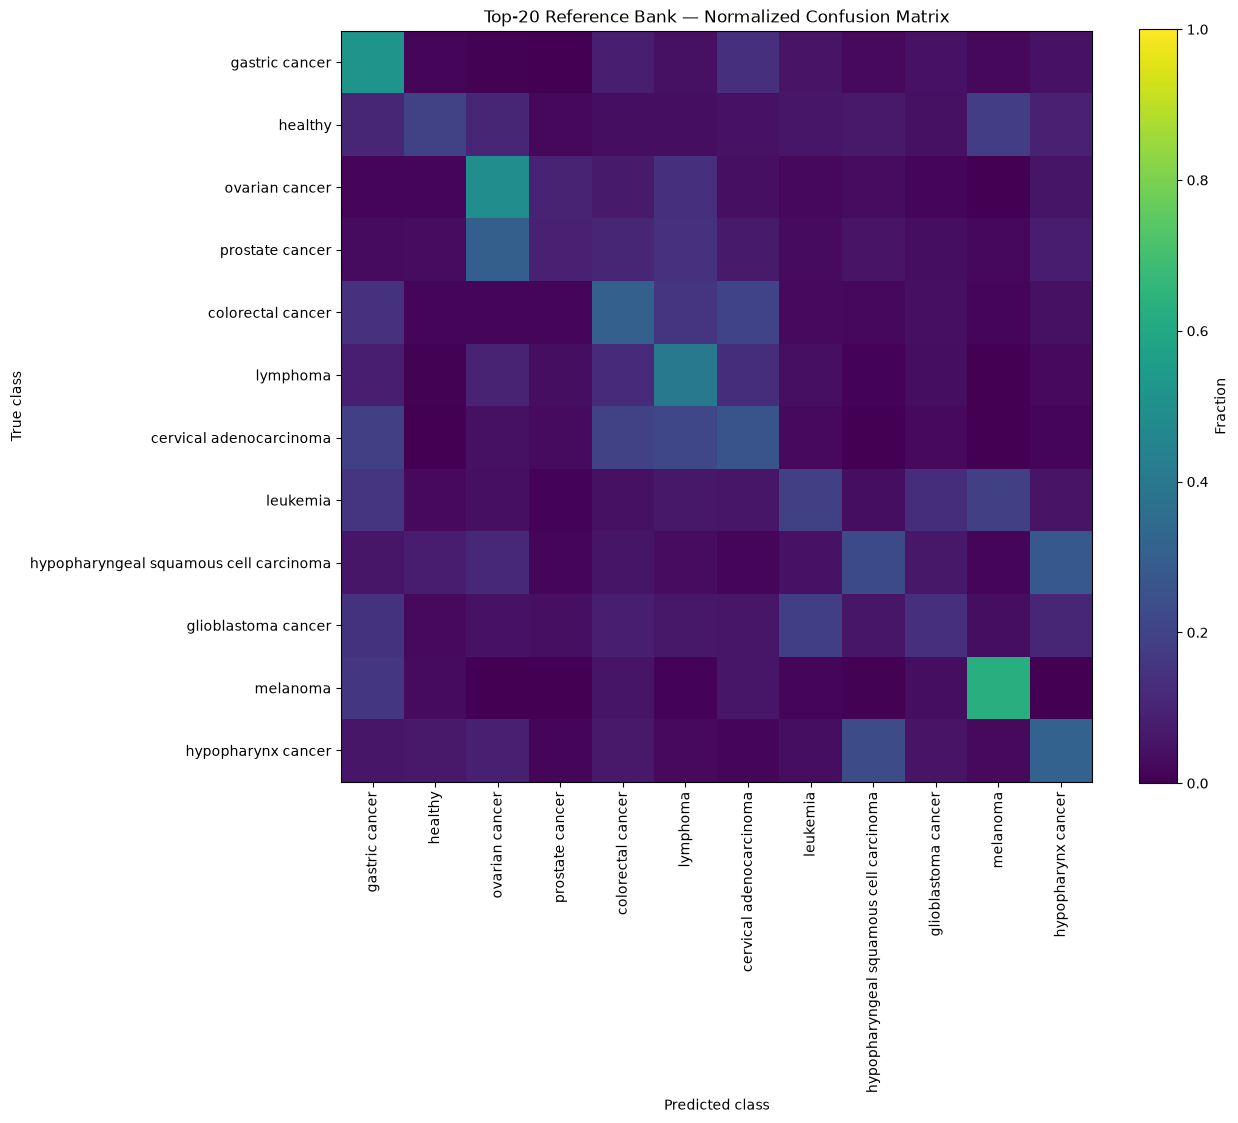

In [15]:
# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    val_labels,
    val_predictions,
    normalize="true"
)


fig, ax = plt.subplots(
    figsize=(13, 11)
)


im = ax.imshow(
    cm,
    vmin=0,
    vmax=1
)


ax.set_xticks(
    np.arange(N_CLASSES)
)

ax.set_yticks(
    np.arange(N_CLASSES)
)


ax.set_xticklabels(
    class_names,
    rotation=90
)

ax.set_yticklabels(
    class_names
)


ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)


ax.set_title(
    "Top-20 Reference Bank — Normalized Confusion Matrix"
)


fig.colorbar(
    im,
    ax=ax,
    label="Fraction"
)


plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# HEALTHY vs TUMOR — DISTANCE TO HEALTHY REFERENCE BANK
# ============================================================

HEALTHY_CLASS_ID = 1
HEALTHY_K = 20


healthy_reference_embeddings = (
    reference_embeddings[
        reference_labels == HEALTHY_CLASS_ID
    ]
)


print(
    "Healthy reference samples:",
    len(healthy_reference_embeddings)
)


healthy_reference_tensor = (
    torch.from_numpy(
        healthy_reference_embeddings
    )
    .float()
    .to(DEVICE)
)


@torch.no_grad()
def healthy_distance_score(
    query_embeddings,
    healthy_references,
    k=20,
    batch_size=256
):

    all_scores = []


    for start in range(
        0,
        len(query_embeddings),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(query_embeddings)
        )


        q = (
            torch.from_numpy(
                query_embeddings[
                    start:end
                ]
            )
            .float()
            .to(DEVICE)
        )


        # Embedding L2-normalizzati:
        # ||a-b||² = 2 - 2*cos(a,b)

        similarity = (
            q
            @
            healthy_references.T
        )


        distances = torch.sqrt(
            torch.clamp(
                2.0
                -
                2.0 * similarity,
                min=0.0
            )
            +
            1e-12
        )


        nearest = torch.topk(
            distances,
            k=k,
            dim=1,
            largest=False
        ).values


        # Più alto = più lontano da Healthy
        # quindi più "tumor-like"
        score = nearest.mean(
            dim=1
        )


        all_scores.append(
            score.cpu().numpy()
        )


    return np.concatenate(
        all_scores
    )


healthy_tumor_scores = healthy_distance_score(
    query_embeddings=val_embeddings,
    healthy_references=healthy_reference_tensor,
    k=HEALTHY_K
)

Healthy reference samples: 2111


In [17]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)


# ============================================================
# BINARY LABELS
# ============================================================

binary_labels = (
    val_labels
    !=
    HEALTHY_CLASS_ID
).astype(np.int64)


binary_auc = roc_auc_score(
    binary_labels,
    healthy_tumor_scores
)


print("=" * 72)
print("HEALTHY vs TUMOR")
print("=" * 72)

print(
    "Healthy samples:",
    (binary_labels == 0).sum()
)

print(
    "Tumor samples:",
    (binary_labels == 1).sum()
)

print(
    "ROC-AUC:",
    f"{binary_auc:.6f}"
)

HEALTHY vs TUMOR
Healthy samples: 1000
Tumor samples: 8753
ROC-AUC: 0.681732


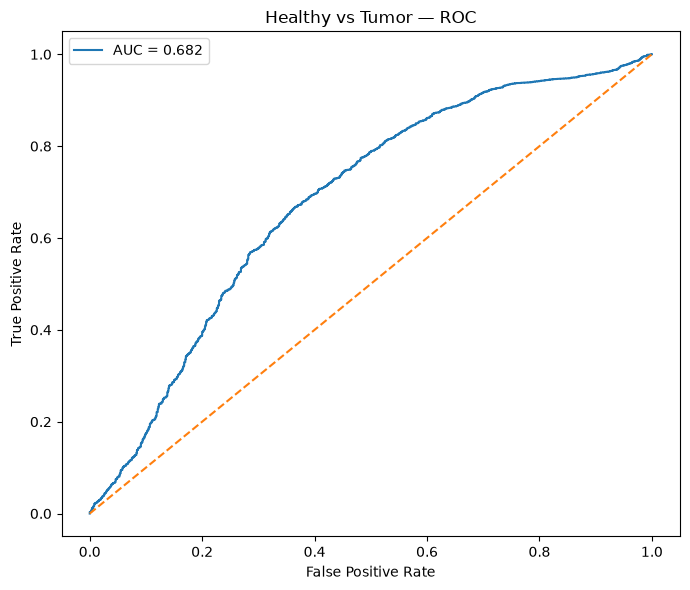

In [18]:
# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    binary_labels,
    healthy_tumor_scores
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


ax.plot(
    fpr,
    tpr,
    label=f"AUC = {binary_auc:.3f}"
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "Healthy vs Tumor — ROC"
)

ax.legend()


plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# BEST VALIDATION THRESHOLD — YOUDEN J
# ============================================================

youden_j = (
    tpr
    -
    fpr
)


best_index = np.argmax(
    youden_j
)


best_threshold = thresholds[
    best_index
]


binary_predictions = (
    healthy_tumor_scores
    >=
    best_threshold
).astype(np.int64)


print("=" * 72)
print("HEALTHY vs TUMOR — VALIDATION THRESHOLD")
print("=" * 72)

print(
    "Threshold:",
    f"{best_threshold:.6f}"
)

print(
    "Accuracy:",
    f"{accuracy_score(binary_labels, binary_predictions):.6f}"
)

print(
    "Balanced Accuracy:",
    f"{balanced_accuracy_score(binary_labels, binary_predictions):.6f}"
)

print(
    "F1:",
    f"{f1_score(binary_labels, binary_predictions):.6f}"
)

HEALTHY vs TUMOR — VALIDATION THRESHOLD
Threshold: 0.182251
Accuracy: 0.664411
Balanced Accuracy: 0.651386
F1: 0.781260
